In [1]:
import utils
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from scipy.stats import fisher_exact
from openpyxl.styles import Font
import seaborn as sns

In [2]:
path_rez = "../data/enrichr/enrichr"
path_set = Path(path_rez)
path_set.mkdir(exist_ok=True)
os.chdir(path_rez)

for patient in utils.patient_ids:
    utils.enrichent_results(utils.up_dict[patient], patient, 'LINCS_L1000_Chem_Pert_down')


In [3]:
#read our initial list of drugs
os.chdir("../..")
df = pd.read_excel("drugs_with_targets.xlsx")

drug_list = (
    df["Name"]
    .astype(str)
    .str.strip()
    .str.lower()
    .tolist()
)

In [4]:
#read the L1000 library
file_path =Path("./enrichr/LINCS_L1000_Chem_Pert_down.txt")
first_terms = []

with file_path.open(encoding="utf-8") as f:
    first_terms = [line.split("\t")[0].strip() for line in f if line.strip()]

In [5]:
# find the common drugs between the initial list from DrugBank and the L1000 library and save them
def normalize(s: str) -> str:
    return " ".join(s.lower().split())    

def find_matching_terms_unique(list1, list2):
    seen = set()
    matches = []

    for s1 in list1:
        n1 = normalize(s1)
        for s2 in list2:
            n2 = normalize(s2)
            key = tuple(sorted((n1, n2)))
            if key not in seen and (n1 in n2 or n2 in n1):
                seen.add(key)
                matches.append((s1, s2))
    return matches

res_match = find_matching_terms_unique(drug_list,first_terms)
common_drugs= {item[0] for item in res_match}
omit=['estradiol benzoate', 'estradiol cypionate']# because are similar to estradiol valerate (estradiol acetate is not included in L1000
common_drugs = [t for t in common_drugs if t not in set(omit)]

values = sorted(common_drugs)    
with open("common_drugs_L1000.txt", "w", encoding="utf-8") as f:
    for value in values:
        f.write(f"{value}\n")

In [6]:
#extract the drugs from each file so that p and padj<0.05 and the name is in the common list (us & EnrichR)
def normalize(s: str) -> str:
    return " ".join(s.lower().split())

def build_dictionary(txt_dir, reference_terms):
    result = {}

    for txt_file in Path(txt_dir).glob("*.txt"):
        matches = set()

        with txt_file.open(encoding="utf-8") as f:
            for line in f:
                cols = line.rstrip("\n").split("\t") 
                col1 = normalize(cols[0])

                try:
                    val2 = float(cols[2])
                    val3 = float(cols[3])
                except ValueError:
                    continue

                if val2 < 0.05 and val3 < 0.05:
                    for term in reference_terms:
                        if term in col1:
                            matches.add(term)

        result[txt_file.stem] = sorted(matches, key=str.lower)

    return result

enrichr_results = build_dictionary("./enrichr/enrichr", common_drugs)
enrichr_primary = {k: v for k, v in enrichr_results.items() if k in utils.list_primary}
enrichr_recurrent = {k: v for k, v in enrichr_results.items() if k in utils.list_recurrent}

In [7]:
# extract all the drugs from our results that correspond to the primary tumor list, and to the recurrent tumor list 
df = pd.read_excel("drugs_for_each_case_in_one_sheet.xlsx")

df_primary = df[df["Patient"].isin(utils.list_primary)]
df_recurrent= df[df["Patient"].isin(utils.list_recurrent)]

key_col = "Patient"  
value_col = "Drug"  

all_primary_results = (
    df_primary.dropna(subset=[key_col, value_col])
      .assign(**{value_col: df[value_col].apply(normalize)})
      .groupby(key_col)[value_col]
      .apply(list)
      .to_dict()
)

all_recurrent_results = (
    df_recurrent.dropna(subset=[key_col, value_col])
      .assign(**{value_col: df[value_col].apply(normalize)})
      .groupby(key_col)[value_col]
      .apply(list)
      .to_dict()
)

In [8]:
#find the drugs that we obtained in all the primary samples
def find_common_drugs(results):

    common_elements = set(results[next(iter(results))])

    for lst in results.values():
        common_elements &= set(lst) 

    common_elements = list(common_elements)
    return common_elements

all_common=find_common_drugs(all_primary_results)
all_common = [t for t in all_common if t not in set(['estradiol benzoate', 'estradiol cypionate','estradiol acetate'])]
print("No of common drugs that we obtained in all our analyzes:",len(all_common))
print("The common drugs that we obtained in all our analyzes:",all_common)

#drugs obtained by us at least once
all_primary_elements = set(e for lst in all_primary_results.values() for e in lst)
all_recurrent_elements = set(e for lst in all_recurrent_results.values() for e in lst)
print("No. of drugs that were obtained at least once in all the analyzes (primary tumors):",len(all_primary_elements))
print("No. of drugs that were obtained at least once in all the analyzes (recurrent tumors):", len(all_recurrent_elements))
print("No. of drugs that were obtained at least once in all the analyzes (primary or recurrent tumors):",len(all_primary_elements|all_recurrent_elements))

No of common drugs that we obtained in all our analyzes: 39
The common drugs that we obtained in all our analyzes: ['estradiol valerate', 'alvocidib', 'nintedanib', 'veliparib', 'decitabine', 'ripretinib', 'imatinib', 'dasatinib', 'belinostat', 'larotrectinib', 'entrectinib', 'olaparib', 'pazopanib', 'rucaparib', 'fingolimod', 'erdafitinib', 'dimethyl fumarate', 'regorafenib', 'gilteritinib', 'carfilzomib', 'seliciclib', 'vinblastine', 'tivozanib', 'trilaciclib', 'choline', 'niraparib', 'crizotinib', 'cisplatin', 'antithymocyte immunoglobulin (rabbit)', 'midostaurin', 'cyclosporine', 'vorinostat', 'talazoparib', 'gemcitabine', 'panobinostat', 'pralsetinib', 'entinostat', 'sunitinib', 'romidepsin']
No. of drugs that were obtained at least once in all the analyzes (primary tumors): 231
No. of drugs that were obtained at least once in all the analyzes (recurrent tumors): 195
No. of drugs that were obtained at least once in all the analyzes (primary or recurrent tumors): 231


In [9]:
# find the drugs that we obtained and are included in the common list
our_primary_results = (
    df_primary.dropna(subset=[key_col, value_col])
      .assign(**{value_col: df[value_col].apply(normalize)})
      .loc[lambda x: x[value_col].isin(common_drugs)]
      .groupby(key_col)[value_col]
      .apply(lambda x: sorted(set(x)))
      .to_dict()
)

our_recurrent_results = (
    df_recurrent.dropna(subset=[key_col, value_col])
      .assign(**{value_col: df[value_col].apply(normalize)})
      .loc[lambda x: x[value_col].isin(common_drugs)]
      .groupby(key_col)[value_col]
      .apply(lambda x: sorted(set(x)))
      .to_dict()
)

our_common=find_common_drugs(our_primary_results)
print("No. of common drugs that we obtained in all our analyzes and are included in the list  of common drugs between us and L1000:",len(our_common))
print("The common drugs that we obtained in all our analyzes and are included in the list  of common drugs between us and L1000:",our_common)

# drugs obtained by us at least once and included in the common list (us and EnrichR)
our_primary_elements = set(e for lst in our_primary_results.values() for e in lst)
our_recurrent_elements = set(e for lst in our_recurrent_results.values() for e in lst)
print("No. of drugs that we obtained at least once in all the analyzes (primary tumors) and are included in the list of common drugs between us and L1000:",len(our_primary_elements))
print("No. of drugs that we obtained at least once in all the analyzes (recurrent tumors) and are included in the list of common drugs between us and L1000:",len(our_recurrent_elements))
print("No. of drugs that were obtained at least once in all the analyzes (primary or recurrent tumors) and are included in the list of common drugs between us and L1000:",len(our_primary_elements|our_recurrent_elements))


No. of common drugs that we obtained in all our analyzes and are included in the list  of common drugs between us and L1000: 20
The common drugs that we obtained in all our analyzes and are included in the list  of common drugs between us and L1000: ['estradiol valerate', 'alvocidib', 'nintedanib', 'veliparib', 'decitabine', 'dasatinib', 'imatinib', 'belinostat', 'olaparib', 'pazopanib', 'rucaparib', 'regorafenib', 'vinblastine', 'tivozanib', 'crizotinib', 'cyclosporine', 'vorinostat', 'gemcitabine', 'entinostat', 'sunitinib']
No. of drugs that we obtained at least once in all the analyzes (primary tumors) and are included in the list of common drugs between us and L1000: 57
No. of drugs that we obtained at least once in all the analyzes (recurrent tumors) and are included in the list of common drugs between us and L1000: 51
No. of drugs that were obtained at least once in all the analyzes (primary or recurrent tumors) and are included in the list of common drugs between us and L1000: 

In [10]:
#where to save the plots
save_path = Path("../data/fig_res")
save_path.mkdir(parents=True, exist_ok=True)

In [19]:
#function to visualize our results in comparison to the L1000 dataset
def plot_comparison(our_results, enrichr_results, dataset):

    sizes_our = [len(v) for v in our_results.values()]
    sizes_enrichr = [len(v) for v in enrichr_results.values()]
    sizes_common = [
        len(set(our_results[k]) & set(enrichr_results[k]))
        for k in our_results
    ]

    data = [sizes_our, sizes_enrichr, sizes_common]
    labels = ["Our method", "L1000", "Overlap"]
    colors = ["#1f77b4", "#d62728", "#2ca02c"]

    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"]
    plt.rcParams["font.size"] = 16

    fig, ax = plt.subplots(figsize=(5.5, 4))

    vp = ax.violinplot( data, showmeans=False, showmedians=True, showextrema=False )

    for body, color in zip(vp["bodies"], colors):
        body.set_facecolor(color)
        body.set_edgecolor("black")
        body.set_alpha(1)

    vp["cmedians"].set_color("black")
    vp["cmedians"].set_linewidth(2)

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(labels,fontweight="bold")
    ax.set_ylabel("Number of drugs per sample",fontweight="bold" )
    ax.set_title("Drug prediction comparison", fontweight="bold" )

    plt.tight_layout()

    plt.savefig(
        f"{save_path}/L1000_comp_{dataset}.eps",
        format="eps",
        dpi=500,
        bbox_inches="tight"
    )

    plt.show()

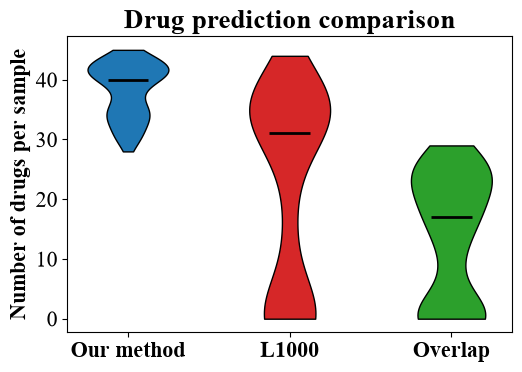

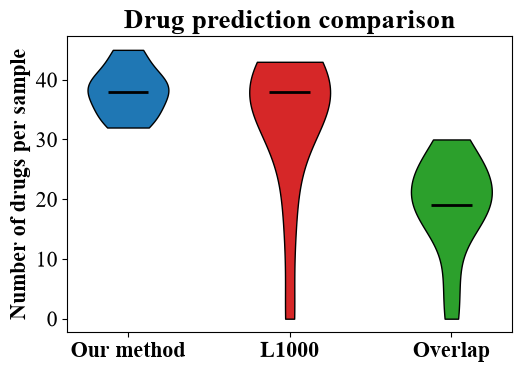

In [20]:
#plot comparisons
plot_comparison(our_primary_results, enrichr_primary,"primary")
plot_comparison(our_recurrent_results, enrichr_recurrent,"recurrent")

In [13]:
# find drug that appeared in all enrichR analyzes and are included in the L1000 common drugs:
enrichr_common=find_common_drugs(enrichr_primary)
print("No. of common drugs obtained in all analyzes performed using the EnrichR platform, which are included in the list of common drugs between us and L1000:",len(enrichr_common))
print(enrichr_common)

#drugs obtained at least once - through EnrichR- included in the common list (us and EnrichR)
enrichr_primary_elements = set(e for lst in enrichr_primary.values() for e in lst)
enrichr_recurrent_elements = set(e for lst in enrichr_recurrent.values() for e in lst)
print("No. of drugs obtained through EnrichR platform at least once in all the analyzes (primary tumors) that are included in the list of common drugs between us and L1000:",len(enrichr_primary_elements))
print("No. of drugs obtained through EnrichR platform at least once in all the analyzes (recurrent tumors) that are included in the list of common drugs between us and L1000:",len(enrichr_recurrent_elements))
print("No. of drugs obtained through EnrichR platform at least once in all the analyzes (primary and recurrent tumors) that are included in the list of common drugs between us and L1000:",len(enrichr_primary_elements|enrichr_recurrent_elements))

No. of common drugs obtained in all analyzes performed using the EnrichR platform, which are included in the list of common drugs between us and L1000: 0
[]
No. of drugs obtained through EnrichR platform at least once in all the analyzes (primary tumors) that are included in the list of common drugs between us and L1000: 54
No. of drugs obtained through EnrichR platform at least once in all the analyzes (recurrent tumors) that are included in the list of common drugs between us and L1000: 48
No. of drugs obtained through EnrichR platform at least once in all the analyzes (primary and recurrent tumors) that are included in the list of common drugs between us and L1000: 56


In [14]:
# differences between us and the results through EnrichR
our_rez= our_primary_elements|our_recurrent_elements
their_rez=enrichr_primary_elements|enrichr_recurrent_elements

print("Drugs identified by our analysis and through EnrichR platform (primary tumor group):",len(our_primary_elements & enrichr_primary_elements))
print("Drugs identified by our analysis and through EnrichR platform (recurrent tumor group):", len(our_recurrent_elements & enrichr_recurrent_elements))
print("Drugs identified only in our analyzes (primary or recurrent):",our_rez-their_rez)
print("Drugs identified only through EnrichR (primary or recurrent):",their_rez-our_rez)
print("Drugs identified only in our analyzes (primary):",our_primary_elements - enrichr_primary_elements)
print("Drugs identified only through EnrichR (primary):",enrichr_primary_elements - our_primary_elements)

Drugs identified by our analysis and through EnrichR platform (primary tumor group): 40
Drugs identified by our analysis and through EnrichR platform (recurrent tumor group): 35
Drugs identified only in our analyzes (primary or recurrent): {'vinblastine', 'tacrolimus', 'estradiol valerate', 'vatalanib', 'genistein', 'cladribine', 'mitotane', 'methotrexate', 'megestrol acetate', 'diethylstilbestrol', 'paclitaxel', 'gemcitabine', 'amsacrine', 'vincristine', 'estradiol', 'tretinoin'}
Drugs identified only through EnrichR (primary or recurrent): {'azacitidine', 'daunorubicin', 'doramapimod', 'lonidamine', 'epirubicin', 'vemurafenib', 'vindesine', 'dactinomycin', 'pf-477736', 'sirolimus', 'mitoxantrone', 'idelalisib', 'palbociclib', 'quizartinib', 'everolimus'}
Drugs identified only in our analyzes (primary): {'vinblastine', 'tacrolimus', 'estradiol valerate', 'vatalanib', 'cladribine', 'genistein', 'mitotane', 'methotrexate', 'megestrol acetate', 'diethylstilbestrol', 'paclitaxel', 'amsacr

In [15]:
#min and max no of drugs at the sample level
list_lengths_primary =sorted(len(v) for v in our_primary_results.values())
list_lengths_recurrent =sorted(len(v) for v in our_recurrent_results.values())
list_lengths_enrichr_p =sorted(len(v) for v in enrichr_primary.values())
list_lengths_enrichr_r =sorted(len(v) for v in enrichr_recurrent.values())

print("The minimum and the maximum no. of drugs we obtained for a patient that are included in the list of common drugs between us and L1000 (primary tumors):", min(list_lengths_primary)," and ",max(list_lengths_primary))
print("The minimum and the maximum no. of drugs we obtained for a patient that are included in the list of common drugs between us and L1000 (recurrent tumors):",min(list_lengths_recurrent), " and ",max(list_lengths_recurrent))
print("The minimum and the maximum no. of drugs obtained for a patient (through EnrichR) that are included in the list of common drugs between us and L1000 (primary tumors):",min(list_lengths_enrichr_p)," and ",max(list_lengths_enrichr_p))
print("The minimum and the maximum no. of drugs obtained for a patient (through EnrichR) that are included in the list of common drugs between us and L1000 (recurrent tumors):",min(list_lengths_enrichr_r), " and ",max(list_lengths_enrichr_r))

# common results with EnrichR
common_primary_per_key={
    k: len(set(our_primary_results [k])&set(enrichr_primary[k]))
    for k in our_primary_results
}

common_recurrent_per_key={
    k: len(set(our_recurrent_results [k])&set(enrichr_recurrent[k]))
    for k in our_recurrent_results
}

list_common_primary =sorted(v for v in common_primary_per_key.values())
list_common_recurrent =sorted(v for v in common_recurrent_per_key.values())
print("The minimum and the maximum no. of drugs common between us and EnrichR (primary tumors):",min(list_common_primary)," and ",max(list_common_primary))
print("The minimum and the maximum no. of drugs common between us and EnrichR (recurrent tumors):",min(list_common_recurrent)," and ",max(list_common_recurrent))

The minimum and the maximum no. of drugs we obtained for a patient that are included in the list of common drugs between us and L1000 (primary tumors): 28  and  45
The minimum and the maximum no. of drugs we obtained for a patient that are included in the list of common drugs between us and L1000 (recurrent tumors): 32  and  45
The minimum and the maximum no. of drugs obtained for a patient (through EnrichR) that are included in the list of common drugs between us and L1000 (primary tumors): 0  and  44
The minimum and the maximum no. of drugs obtained for a patient (through EnrichR) that are included in the list of common drugs between us and L1000 (recurrent tumors): 0  and  43
The minimum and the maximum no. of drugs common between us and EnrichR (primary tumors): 0  and  29
The minimum and the maximum no. of drugs common between us and EnrichR (recurrent tumors): 0  and  30


In [16]:
#apply Fisher Exact Test for each sample, save the results and see the number of samples with odds>1 and pvalue<0.05
def fisher(list1,list2):

    if not list1 or not list2:
        return None, None

    set1, set2 = set(list1), set(list2)
    table = [[len(set1 & set2),len(set1-set2)],  [len(set2-set1), (109-len(set1|set2))]]
    odds_ratio, p_value = fisher_exact(table, alternative='greater')

    return odds_ratio,p_value

fisher_primary_per_key={
    k: fisher(our_primary_results [k], enrichr_primary[k])
    for k in our_primary_results
}

fisher_recurrent_per_key={
    k: fisher(our_recurrent_results [k], enrichr_recurrent[k])
    for k in our_recurrent_results
}

def fisher_to_excel(dict_fisher, sheet_name, title):

    clean_dict = {
        k: v for k, v in dict_fisher.items()
        if v is not None and v[0] is not None
    }

    df_fisher = pd.DataFrame.from_dict(
        clean_dict,
        orient="index",
        columns=["Odds ratio", "p value"]
    ).reset_index()

    from statsmodels.stats.multitest import multipletests

    df_fisher["Adjusted P-value"] = multipletests(
        df_fisher["p value"],
        method="fdr_bh"
    )[1]

    df_fisher["Significant"] = df_fisher["Adjusted P-value"] < 0.05

    df_fisher.rename(columns={"index": "Sample"}, inplace=True)

    df_fisher = df_fisher.sort_values("Adjusted P-value")

    file_exists = os.path.exists("Fisher_results.xlsx")

    with pd.ExcelWriter(
        "Fisher_results.xlsx",
        engine="openpyxl",
        mode="a" if file_exists else "w",
        if_sheet_exists="replace"
    ) as writer:

        df_fisher.to_excel(
            writer,
            sheet_name=sheet_name,
            startrow=3,
            index=False
        )

        workbook = writer.book
        worksheet = workbook[sheet_name]

        worksheet["A1"] = title
        worksheet["A1"].font = Font(size=14, bold=True)

    return df_fisher
    
primary_df = fisher_to_excel(fisher_primary_per_key ,"primary" ,"Fisher test results for primary tumors" ) 
recurrent_df = fisher_to_excel(fisher_recurrent_per_key,"recurrent" ,"Fisher test results for recurrent tumors" )

def see_association(group, fisher_df):

    odds_nr = (fisher_df["Odds ratio"] > 1).sum()
    sig_nr = (fisher_df["Adjusted P-value"] < 0.05).sum()

    print(group)
    print("Odds ratio > 1:", odds_nr)
    print("Adjusted P-value < 0.05:", sig_nr)

see_association("Primary tumors", primary_df)
see_association("Recurrent tumors", recurrent_df)
#see_association("primary tumor samples from 134 samples have the odds more than 1","primary tumor samples from 134 samples have the pvalue less than 0.05", fisher_primary_per_key)
#see_association("recurrent tumor samples from 13 samples have the odds more than 1","recurrent tumor samples from 13 samples have the pvalue less than 0.05", fisher_recurrent_per_key)

Primary tumors
Odds ratio > 1: 99
Adjusted P-value < 0.05: 87
Recurrent tumors
Odds ratio > 1: 12
Adjusted P-value < 0.05: 11


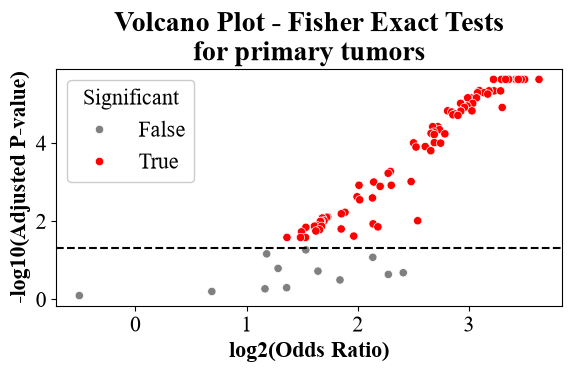

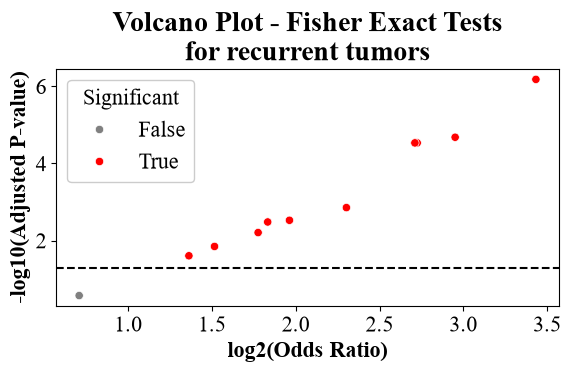

In [17]:
# volcano plots for the results
def volcano_plot(fisher_df, name, file_save):

    df_Fisher = fisher_df.copy()

    df_Fisher["log2_OR"] = np.log2(df_Fisher["Odds ratio"])
    df_Fisher["neg_log10_padj"] = -np.log10(df_Fisher["Adjusted P-value"])

    df_Fisher["significant"] = (
        df_Fisher["Adjusted P-value"] < 0.05
    )

    alpha1 = 0.05

    plt.figure(figsize=(6,4))

    sns.scatterplot(
        data=df_Fisher,
        x="log2_OR",
        y="neg_log10_padj",
        hue="significant",
        palette={True: "red", False: "gray"},
        alpha=1
            )

    legend = plt.legend(title="Significant")
    legend.get_frame().set_alpha(1)

    plt.axhline( -np.log10(alpha1), linestyle="--", color="black" )
    plt.xlabel( "log2(Odds Ratio)", fontsize=16, fontfamily="Times New Roman", fontweight="bold" )
    plt.ylabel("-log10(Adjusted P-value)", fontsize=16, fontfamily="Times New Roman", fontweight="bold" )
    plt.title( "Volcano Plot - Fisher Exact Tests\nfor " + name,  fontsize=20, fontfamily="Times New Roman", fontweight="bold" )

    plt.tight_layout()
    plt.savefig(
        str(save_path)+"/"+file_save,
        format="eps",
        dpi=500,
        bbox_inches="tight"
    )

    plt.show()
volcano_plot( primary_df, "primary tumors", "primary_volcano.eps")
volcano_plot(recurrent_df, "recurrent tumors", "Volcano_recurrent.eps")

In [18]:
# statistics on the generic network
df_all = df[df["Patient"]=="all"]

df_all_results = (
    df_all.dropna(subset=[key_col, value_col])
      .assign(**{value_col: df[value_col].apply(normalize)})
      .loc[lambda x: x[value_col].isin(common_drugs)]
      .groupby(key_col)[value_col]
      .apply(list)
      .to_dict())

rez_all=fisher(df_all_results["all"],enrichr_results["all"])

print("Generic analysis - the no. of drugs we obtained that are also included in the list of common drugs beween us and L1000:",len(df_all_results["all"]))
print("Generic analysis - the no. of drugs obtained through EnrichR that are also included in the list of common drugs beween us and L1000:",len(enrichr_results["all"]))
print("Generic analysis - the no. of common drugs obtained by us and through EnrichR:", len(set(df_all_results["all"])&set(enrichr_results["all"])))
print("Generic analysis - Fisher Exact Test:",rez_all)

Generic analysis - the no. of drugs we obtained that are also included in the list of common drugs beween us and L1000: 41
Generic analysis - the no. of drugs obtained through EnrichR that are also included in the list of common drugs beween us and L1000: 35
Generic analysis - the no. of common drugs obtained by us and through EnrichR: 25
Generic analysis - Fisher Exact Test: (np.float64(9.0625), np.float64(7.900818406683471e-07))
